## Figure 2 -- Constraints between elements of the overlap matrix
---
Fig. 2 shows the **minimum** achievable intra-order overlap $\mathrm{Min}\,\mathcal T^{(2)}_i$ of a node as a function of its generalized connectivities $(k^{(2)}_i,k^{(3)}_i)$, **given** $\mathcal I^{(2,3)}=1$ (the caption's final "$=0$" is a typo; correct value is $\mathcal I^{(2,3)}=1$).

Panel (a): $\mathcal T^{(3)}=1$;

panel (b): $\mathcal T^{(3)}=0$.

Red dots mark the minimum $k^{(2)}_i$ needed to reach $\mathcal I^{(2,3)}=1$.

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.getcwd())
import util
sys.path.insert(0, util.OVERLAP_DIR)
from hyperedge_overlap_utils import (intra_order_hyperedge_overlap as intra_overlap,
                                      inter_order_hyperedge_overlap as inter_overlap)
rng_seed = 0

In [2]:
from hyperedge_overlap_utils import Splus_boundary, Sminus_boundary
from math import comb, ceil, sqrt

def min_T2_given_I23(k2, k3, T3):
    '''Minimum intra-order overlap T^(2)_i of a node with connectivities
    (k2,k3) when the inter-order overlap with 3-hyperedges is maximal
    (I^(2,3)=1). Implements Eq. (7)-(8) with m=2, n=3.

    S^(3)_i is set by T3 (the intra-order overlap of the 3-hyperedges):
      T3=1 (max intra overlap of order 3): S3 = S3^- = ceil(y3),
          y3(y3-1)(y3-2) = 6 k3
      T3=0 (min intra overlap of order 3): S3 = 3 k3
    Then S2^min = S3 + m*(k2 - C(S3, m)),  m=2, and T2 via Eq.(4) boundaries.
    Returns np.nan where the configuration is infeasible (k2 < X).
    '''
    m = 2
    if k2 < 1 or k3 < 1:
        return np.nan
    if T3 == 1:
        # solve y(y-1)(y-2) = 6 k3
        y = 3.0
        for _ in range(200):
            f = y*(y-1)*(y-2) - 6*k3
            df = (3*y*y - 6*y + 2)
            y = y - f/df
        S3 = int(ceil(y))
    else:  # T3 == 0
        S3 = 3*k3
    X = comb(S3, m)          # possible 2-cliques inside the 3-hyperedge neighbourhood
    if k2 < X:               # infeasible: cannot reach I^(2,3)=1
        return np.nan
    S2 = S3 + m*(k2 - X)
    Splus  = Splus_boundary(m, k2)      # = m*k2
    Sminus = Sminus_boundary(m, k2)     # smallest #neighbours
    if Splus == Sminus:
        return 0.0
    T2 = 1 - (S2 - Sminus)/(Splus - Sminus)
    return T2

def min_k2_for_I23_1(k3, T3):
    '''Red-dot curve: minimum k2 so that I^(2,3)=1 is reachable (k2 >= C(S3,2)).'''
    if T3 == 1:
        y = 3.0
        for _ in range(200):
            f = y*(y-1)*(y-2) - 6*k3
            df = (3*y*y - 6*y + 2)
            y = y - f/df
        S3 = int(ceil(y))
    else:
        S3 = 3*k3
    return comb(S3, 2)

In [3]:
def make_fig2_panel(ax, T3, k3_max, k2_max, step2=1, step3=1, title=""):
    k3_vals = np.arange(1, k3_max+1, step3)
    k2_vals = np.arange(1, k2_max+1, step2)
    Z = np.full((len(k2_vals), len(k3_vals)), np.nan)
    for a, k2 in enumerate(k2_vals):
        for b, k3 in enumerate(k3_vals):
            Z[a, b] = min_T2_given_I23(int(k2), int(k3), T3)
    im = ax.pcolormesh(k3_vals, k2_vals, Z, shading="auto", cmap=plt.colormaps['mako'],
                       vmin=0, vmax=1)
    # red dots: min k2 required for I^(2,3)=1
    reds_x, reds_y = [], []
    for k3 in k3_vals:
        mk2 = min_k2_for_I23_1(int(k3), T3)
        if mk2 <= k2_max:
            reds_x.append(k3); reds_y.append(mk2)
    ax.set_box_aspect(1)
    ax.plot(reds_x, reds_y, "r.", ms=4)
    ax.set_xlabel(r"$k_i^{(3)}$")
    ax.set_ylabel(r"$k_i^{(2)}$", rotation=0)
    ax.set_title(title)
    return im

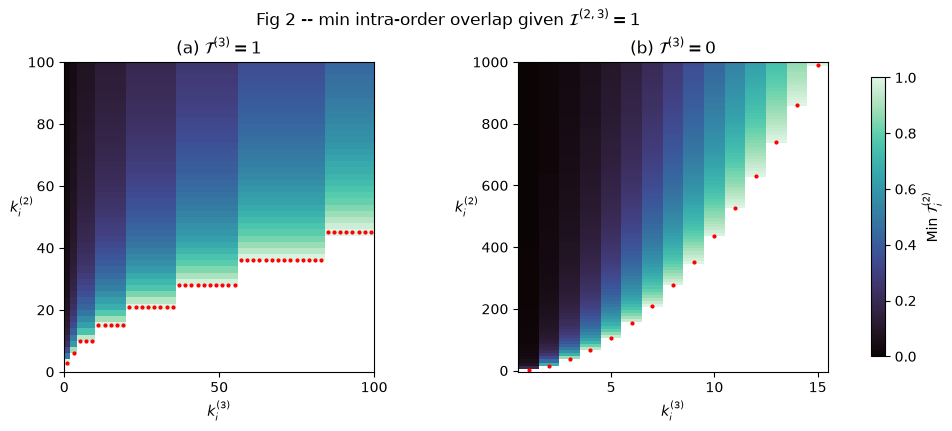

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), constrained_layout=True)

im_a = make_fig2_panel(axes[0], T3=1, k3_max=100, k2_max=100, step2=2, step3=2,
                       title=r"(a) $\mathcal{T}^{(3)}=1$")
axes[0].set_xticks([0, 50, 100])
axes[0].set_yticks([0, 20, 40, 60, 80, 100])

im_b = make_fig2_panel(axes[1], T3=0, k3_max=15, k2_max=1000, step2=10, step3=1,
                       title=r"(b) $\mathcal{T}^{(3)}=0$")
axes[1].set_xticks([5, 10, 15])
axes[1].set_yticks([0, 200, 400, 600, 800, 1000])
cb = fig.colorbar(im_b, ax=axes, shrink=0.9); cb.set_label(r"Min $\mathcal{T}_i^{(2)}$")
fig.suptitle(r"Fig 2 -- min intra-order overlap given $\mathcal{I}^{(2,3)}=1$")
plt.show()

fig.savefig("figures/Fig2.png", dpi=300, bbox_inches="tight")